# **Analyzing Movie Ratings and User Preferences using Big Data**


In [3]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, broadcast, sum as spark_sum, collect_list, udf
from pyspark.ml.linalg import Vectors
from pyspark.sql.types import ArrayType, FloatType

spark = SparkSession.builder \
    .appName("UserBasedCF") \
    .getOrCreate()


In [4]:
ratings = spark.read.csv('/content/ratings.csv',sep=',',header=True, inferSchema=True)
movies = spark.read.csv('/content/movies.csv', sep=',',header=True, inferSchema=True)

In [5]:
print("Ratings columns:", ratings.columns)
print("Movies columns:", movies.columns)

Ratings columns: ['userId', 'movieId', 'rating', 'timestamp']
Movies columns: ['movieId', 'title', 'genres']


In [33]:
ratings.count()

32000204

In [34]:
movies.select("movieId").distinct().count()

87585

# **DATA PREPROCESSING**

In [35]:
ratings = ratings.dropna()
movies = movies.dropna()

In [37]:
from pyspark.sql.functions import from_unixtime

ratings = ratings.withColumn(
    "date",
    from_unixtime("timestamp").cast("date")
)


# **USER BASED COLLABORATIVE FILTERING**

In [8]:
from pyspark.sql.functions import collect_list

user_item = ratings.groupBy("userId").agg(
    collect_list("movieId").alias("movies"),
    collect_list("rating").alias("ratings")
)

user_item.show(5)


+------+--------------------+--------------------+
|userId|              movies|             ratings|
+------+--------------------+--------------------+
|     1|[17, 25, 29, 30, ...|[4.0, 1.0, 2.0, 5...|
|     3|[2, 10, 11, 17, 2...|[3.5, 4.0, 4.0, 5...|
|     5|[10, 47, 110, 150...|[4.0, 3.0, 4.0, 3...|
|     6|[590, 839, 1556, ...|[4.0, 5.0, 5.0, 4...|
|    12|[31, 261, 356, 66...|[3.0, 3.0, 3.0, 2...|
+------+--------------------+--------------------+
only showing top 5 rows


In [9]:
from pyspark.ml.linalg import Vectors
from pyspark.sql.functions import udf
from pyspark.sql.types import ArrayType, FloatType

def to_float_array(r):
    return [float(x) for x in r]

to_float_udf = udf(to_float_array, ArrayType(FloatType()))

user_vectors = user_item.withColumn(
    "rating_vector",
    to_float_udf("ratings")
)

user_vectors.show(5)


+------+--------------------+--------------------+--------------------+
|userId|              movies|             ratings|       rating_vector|
+------+--------------------+--------------------+--------------------+
|     1|[17, 25, 29, 30, ...|[4.0, 1.0, 2.0, 5...|[4.0, 1.0, 2.0, 5...|
|     3|[2, 10, 11, 17, 2...|[3.5, 4.0, 4.0, 5...|[3.5, 4.0, 4.0, 5...|
|     5|[10, 47, 110, 150...|[4.0, 3.0, 4.0, 3...|[4.0, 3.0, 4.0, 3...|
|     6|[590, 839, 1556, ...|[4.0, 5.0, 5.0, 4...|[4.0, 5.0, 5.0, 4...|
|    12|[31, 261, 356, 66...|[3.0, 3.0, 3.0, 2...|[3.0, 3.0, 3.0, 2...|
+------+--------------------+--------------------+--------------------+
only showing top 5 rows


In [10]:
import math

def cosine_similarity(v1, v2):
    dot = sum(a*b for a, b in zip(v1, v2))
    norm1 = math.sqrt(sum(a*a for a in v1))
    norm2 = math.sqrt(sum(b*b for b in v2))
    if norm1 == 0 or norm2 == 0:
        return 0.0
    return dot / (norm1 * norm2)


In [11]:
from pyspark.sql.functions import col

target_user = 1
target_vector = user_vectors.filter(col("userId") == target_user).collect()[0]["rating_vector"]

similarity_udf = udf(
    lambda x: cosine_similarity(x, target_vector),
    FloatType()
)

user_similarity = user_vectors.withColumn(
    "similarity", similarity_udf("rating_vector")
).filter(col("userId") != target_user)

user_similarity.orderBy(col("similarity").desc()).show(5)


+------+--------------------+--------------------+--------------------+----------+
|userId|              movies|             ratings|       rating_vector|similarity|
+------+--------------------+--------------------+--------------------+----------+
| 32858|[19, 47, 231, 337...|[2.0, 5.0, 2.5, 5...|[2.0, 5.0, 2.5, 5...|  0.918558|
| 36286|[16, 47, 50, 110,...|[5.0, 5.0, 5.0, 5...|[5.0, 5.0, 5.0, 5...|0.91766715|
|119300|[1, 10, 135, 150,...|[5.0, 5.0, 5.0, 5...|[5.0, 5.0, 5.0, 5...|0.91737443|
| 87404|[19, 50, 95, 110,...|[4.0, 4.5, 4.5, 5...|[4.0, 4.5, 4.5, 5...| 0.9167386|
|115610|[1, 3, 47, 58, 73...|[3.5, 3.0, 3.5, 5...|[3.5, 3.0, 3.5, 5...| 0.9164608|
+------+--------------------+--------------------+--------------------+----------+
only showing top 5 rows


In [12]:
top_users = user_similarity.orderBy(col("similarity").desc()).limit(5)
recommended_movies = ratings.join(
    top_users.select("userId"),
    "userId"
).join(movies, "movieId")

recommended_movies.select("title", "rating").show(10)


+--------------------+------+
|               title|rating|
+--------------------+------+
|Ace Ventura: When...|   2.0|
|Seven (a.k.a. Se7...|   5.0|
|Dumb & Dumber (Du...|   2.5|
|What's Eating Gil...|   5.0|
| Forrest Gump (1994)|   5.0|
|Lion King, The (1...|   5.0|
|Mrs. Doubtfire (1...|   3.0|
|Schindler's List ...|   5.0|
|Nightmare Before ...|   4.0|
|Beauty and the Be...|   4.0|
+--------------------+------+
only showing top 10 rows


# **ITEM BASED COLLABORATIVE FILTERING**

In [14]:
from pyspark.sql.functions import collect_list

item_profiles = ratings.groupBy("movieId").agg(
    collect_list("userId").alias("users"),
    collect_list("rating").alias("ratings")
)

item_profiles.show(5)


+-------+--------------------+--------------------+
|movieId|               users|             ratings|
+-------+--------------------+--------------------+
|      1|[10, 26337, 11, 2...|[2.5, 3.5, 3.0, 5...|
|      3|[11, 26348, 28, 2...|[3.0, 3.0, 4.0, 1...|
|      6|[13363, 11, 13367...|[4.5, 3.0, 4.0, 5...|
|     12|[13455, 143, 1349...|[3.0, 3.0, 2.0, 3...|
|     13|[43, 26428, 73, 2...|[2.0, 2.5, 3.0, 3...|
+-------+--------------------+--------------------+
only showing top 5 rows


In [15]:
from pyspark.sql.types import ArrayType, FloatType
from pyspark.sql.functions import udf

def to_float_array(r):
    return [float(x) for x in r]

to_float_udf = udf(to_float_array, ArrayType(FloatType()))

item_vectors = item_profiles.withColumn(
    "rating_vector",
    to_float_udf("ratings")
)

item_vectors.show(5)


+-------+--------------------+--------------------+--------------------+
|movieId|               users|             ratings|       rating_vector|
+-------+--------------------+--------------------+--------------------+
|      1|[10, 26337, 11, 2...|[2.5, 3.5, 3.0, 5...|[2.5, 3.5, 3.0, 5...|
|      3|[11, 26348, 28, 2...|[3.0, 3.0, 4.0, 1...|[3.0, 3.0, 4.0, 1...|
|      6|[13363, 11, 13367...|[4.5, 3.0, 4.0, 5...|[4.5, 3.0, 4.0, 5...|
|     12|[13455, 143, 1349...|[3.0, 3.0, 2.0, 3...|[3.0, 3.0, 2.0, 3...|
|     13|[43, 26428, 73, 2...|[2.0, 2.5, 3.0, 3...|[2.0, 2.5, 3.0, 3...|
+-------+--------------------+--------------------+--------------------+
only showing top 5 rows


In [16]:
import math

def cosine_similarity(v1, v2):
    dot = sum(a*b for a, b in zip(v1, v2))
    norm1 = math.sqrt(sum(a*a for a in v1))
    norm2 = math.sqrt(sum(b*b for b in v2))
    if norm1 == 0 or norm2 == 0:
        return 0.0
    return dot / (norm1 * norm2)


In [17]:
target_movie = 1
target_vector = item_vectors.filter(
    item_vectors.movieId == target_movie
).collect()[0]["rating_vector"]


In [18]:
from pyspark.sql.functions import col
from pyspark.sql.types import FloatType

similarity_udf = udf(
    lambda x: cosine_similarity(x, target_vector),
    FloatType()
)

item_similarity = item_vectors.withColumn(
    "similarity", similarity_udf("rating_vector")
).filter(col("movieId") != target_movie)

item_similarity.orderBy(col("similarity").desc()).show(5)


+-------+--------------------+--------------------+--------------------+----------+
|movieId|               users|             ratings|       rating_vector|similarity|
+-------+--------------------+--------------------+--------------------+----------+
|     50|[9, 26397, 10, 26...|[4.0, 5.0, 4.0, 4...|[4.0, 5.0, 4.0, 4...| 0.9483847|
|    589|[13394, 3, 13402,...|[3.5, 3.0, 4.0, 4...|[3.5, 3.0, 4.0, 4...|0.94440585|
|    110|[26390, 3, 26395,...|[5.0, 5.0, 5.0, 4...|[5.0, 5.0, 5.0, 4...|0.94231546|
|   1198|[3, 13405, 10, 13...|[4.5, 5.0, 3.5, 2...|[4.5, 5.0, 3.5, 2...|0.94130623|
|   1210|[13394, 26391, 13...|[3.5, 5.0, 4.0, 3...|[3.5, 5.0, 4.0, 3...|0.93671536|
+-------+--------------------+--------------------+--------------------+----------+
only showing top 5 rows


In [19]:
item_recommendations = item_similarity.join(
    movies, "movieId"
)

item_recommendations.select(
    "title", "similarity"
).orderBy(col("similarity").desc()).show(10, truncate=False)


+------------------------------------------------------------------------------+----------+
|title                                                                         |similarity|
+------------------------------------------------------------------------------+----------+
|Usual Suspects, The (1995)                                                    |0.9483847 |
|Terminator 2: Judgment Day (1991)                                             |0.94440585|
|Braveheart (1995)                                                             |0.94231546|
|Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)|0.94130623|
|Star Wars: Episode VI - Return of the Jedi (1983)                             |0.93671536|
|Godfather, The (1972)                                                         |0.9362269 |
|Lord of the Rings: The Two Towers, The (2002)                                 |0.9351798 |
|Lord of the Rings: The Return of the King, The (2003)                         |

# **VISUALIZATION & INSIGHTS**

# **USER ACTIVITY PATTERN**

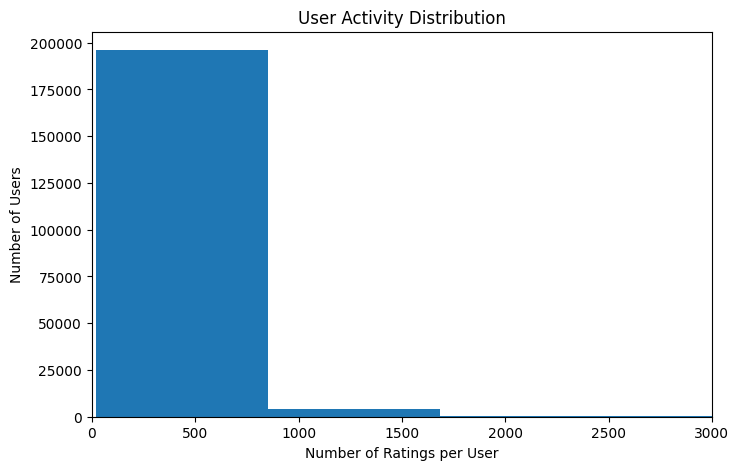

In [21]:
import matplotlib.pyplot as plt

user_activity_pd = user_stats.select("num_ratings").toPandas()

plt.figure(figsize=(8,5))
plt.hist(user_activity_pd["num_ratings"], bins=40)
plt.xlim(0, 3000)
plt.xlabel("Number of Ratings per User")
plt.ylabel("Number of Users")
plt.title("User Activity Distribution")
plt.show()


# **TOP RATED MOVIES**

In [24]:
from pyspark.sql.functions import avg, count, col

movie_stats = ratings.groupBy("movieId").agg(
    avg("rating").alias("avg_rating"),
    count("userId").alias("num_users")
).join(movies, "movieId")

top_movies_pd = movie_stats \
    .select("title", "avg_rating") \
    .orderBy(col("avg_rating").desc()) \
    .limit(10) \
    .toPandas()

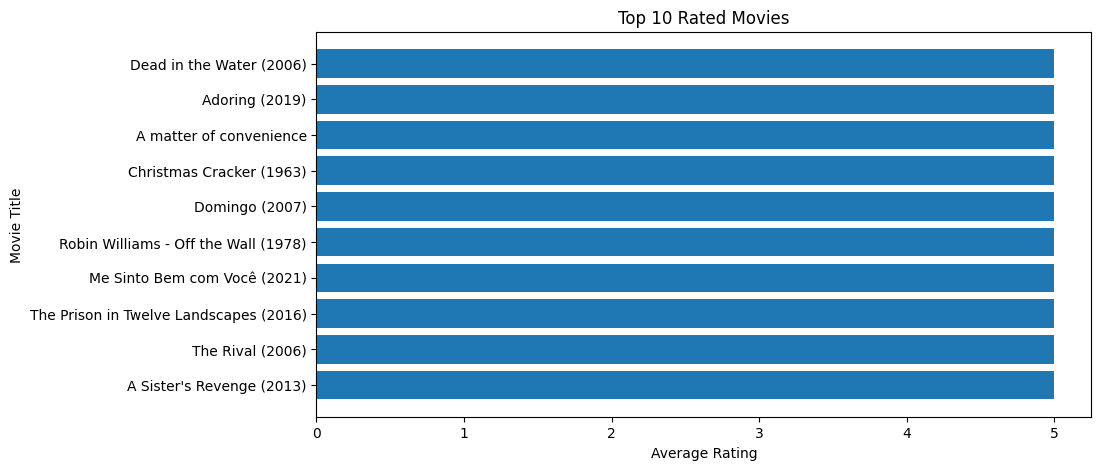

In [25]:
plt.figure(figsize=(10,5))
plt.barh(top_movies_pd["title"], top_movies_pd["avg_rating"])
plt.xlabel("Average Rating")
plt.ylabel("Movie Title")
plt.title("Top 10 Rated Movies")
plt.gca().invert_yaxis()
plt.show()

# **RATINGS TREND OVER TIME**

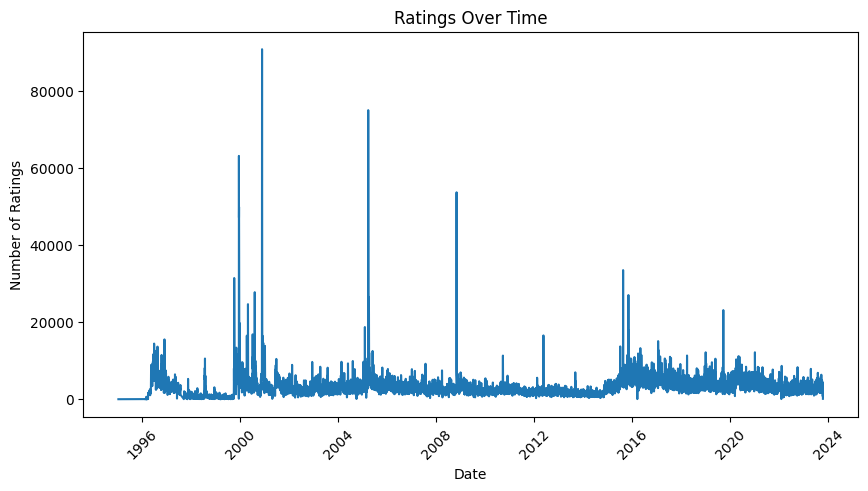

In [27]:
from pyspark.sql.functions import count

ratings_over_time = ratings.groupBy("date").agg(count("rating").alias("count")).orderBy("date")

ratings_time_pd = ratings_over_time.toPandas()
plt.figure(figsize=(10,5))
plt.plot(ratings_time_pd["date"], ratings_time_pd["count"])
plt.xlabel("Date")
plt.ylabel("Number of Ratings")
plt.title("Ratings Over Time")
plt.xticks(rotation=45)
plt.show()

# **GENRE POPULARITY**

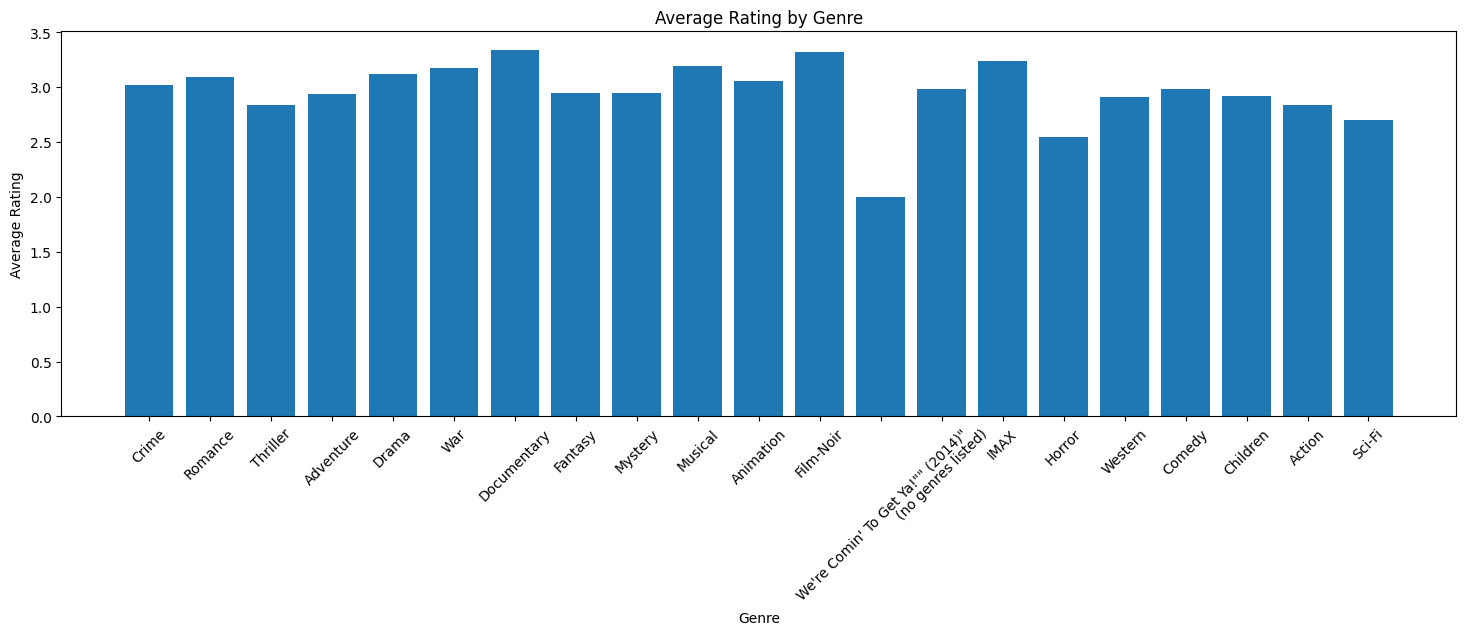

In [32]:
from pyspark.sql.functions import explode, split

genre_trends = movie_stats.withColumn(
    "genre", explode(split("genres", "\\|"))
).groupBy("genre").avg("avg_rating")

genre_pd = genre_trends.toPandas()

plt.figure(figsize=(18,5))
plt.bar(genre_pd["genre"], genre_pd["avg(avg_rating)"])
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.title("Average Rating by Genre")
plt.xticks(rotation=45)
plt.show()